In [17]:
# ==========================================
# Edmonton Real Estate Capstone
# Spatial Enrichment – Latitude & Longitude
# ==========================================

# ------------------------------------------
# Step 1: Import Libraries
# ------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

#### Step 1: Import Libraries

In this step, we import the tools needed for the project.

- `pandas` → to handle and organize the dataset  
- `matplotlib` → to create charts  
- `Nominatim` → to convert addresses to latitude and longitude  
- `RateLimiter` → to prevent too many requests at once  

This prepares us for data analysis and spatial mapping.

In [18]:
# ------------------------------------------
# Step 2: Load Dataset
# ------------------------------------------

base_path = r"C:\Users\Adewale Sam\Desktop\DATA3960 - Data Analytics Capstone"

sold_df = pd.read_csv(
    f"{base_path}\\RealEstateDataJanuary2026-Data3960-sold.csv",
    encoding='cp1252',
    low_memory=False
)

print("Dataset loaded.")
print("Original shape:", sold_df.shape)

Dataset loaded.
Original shape: (515122, 48)


#### Step 2: Load Dataset

We loaded the real estate data into a table called `sold_df`.  
- The dataset has **515,122 rows** (each row = a house sold)  
- And **48 columns** (each column = a detail like price, size, location)  

This confirms all our data is ready for analysis.

#### Why the Sold Dataset Was Used for Analysis

For this analysis, the **sold dataset** was used instead of the active listings dataset.

The main reason is that the sold dataset contains the **actual transaction prices** of properties. This means it reflects the real amount buyers paid, not just the price sellers were asking.

Using sold data provides:

- More accurate market value insights  
- Reliable price analysis based on completed transactions  
- Better understanding of the relationship between property features and actual sale price  
- More realistic conclusions about the Edmonton housing market  

In contrast, active listings only show asking prices, which may be higher than what the property eventually sells for or may never result in a sale.

Therefore, the sold dataset provides stronger, more reliable data for meaningful market analysis.

In [19]:

# ------------------------------------------
# Step 3: Clean Column Names
# ------------------------------------------

sold_df.columns = (
    sold_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=True)
    .str.replace('/', '_', regex=True)
)

print("Columns cleaned.")

Columns cleaned.


#### Step 3: Clean Column Names

We cleaned up the column names to make them easier to work with:  
- Removed extra spaces  
- Converted all letters to lowercase  
- Replaced spaces and slashes with underscores  

This makes it simpler to reference columns in our analysis.  

**Result:** Columns cleaned.

In [20]:
# ------------------------------------------
# Step 4: Filter Edmonton Only
# ------------------------------------------

sold_df = sold_df[sold_df['area_city'].str.contains("edmonton", case=False, na=False)]

print("After Edmonton filter:", sold_df.shape)


After Edmonton filter: (344504, 48)


#### Step 4: Filter Edmonton Only

We filtered the data to include **only houses in Edmonton**.  
- Before: 515,122 houses  
- After: 344,504 houses  

This keeps our analysis focused on Edmonton properties.  

**Result:** After Edmonton filter: (344,504 rows, 48 columns)

In [21]:
# ------------------------------------------
# Step 5: Create Full Address Column
# ------------------------------------------

sold_df['full_address'] = (
    sold_df['address'].astype(str) + ", Edmonton, Alberta, Canada"
)

print("Full address created.")
print(sold_df['full_address'].head())

Full address created.
32191    885 ABBOTTSFIELD Road NW, Edmonton, Alberta, C...
32192    904 ABBOTTSFIELD Road NW, Edmonton, Alberta, C...
32193    791 ABBOTTSFIELD Road NW, Edmonton, Alberta, C...
32194    168 ABBOTTSFIELD Road NW, Edmonton, Alberta, C...
32195    701 ABBOTTSFIELD Road NW, Edmonton, Alberta, C...
Name: full_address, dtype: object


#### Step 5: Create Full Address Column

We combined the house address with the city, province, and country to make a **full address** for each property.  
- This full address will be used later to find the latitude and longitude for mapping.

In [22]:
# ------------------------------------------
# Step 6: Sample Data (VERY IMPORTANT)
# ------------------------------------------

geo_sample = sold_df.sample(1000, random_state=42).copy()

print("Sample size for geocoding:", geo_sample.shape)

Sample size for geocoding: (1000, 49)


#### Step 6: Sample Data (VERY IMPORTANT)

We take a **small random sample** of 1,000 houses from the dataset.  
- This makes geocoding faster and avoids overloading the mapping service.  
- It’s a representative subset of the full data for testing purposes.

In [23]:
# ------------------------------------------
# Step 7: Initialize Geocoder
# ------------------------------------------

geolocator = Nominatim(user_agent="edmonton_real_estate_project")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

#### Step 7: Initialize Geocoder

We set up a tool to convert addresses into **latitude and longitude**.  
- `Nominatim` is the service that looks up addresses.  
- `RateLimiter` makes sure we don’t send requests too fast and get blocked.

In [24]:
# ------------------------------------------
# Step 8: Apply Geocoding
# ------------------------------------------

print("Geocoding started... This will take some time.")

geo_sample['location'] = geo_sample['full_address'].apply(geocode)

geo_sample['latitude'] = geo_sample['location'].apply(lambda loc: loc.latitude if loc else None)
geo_sample['longitude'] = geo_sample['location'].apply(lambda loc: loc.longitude if loc else None)

print("Geocoding complete.")

Geocoding started... This will take some time.
Geocoding complete.


#### Step 8: Apply Geocoding

We use the geocoder to find the **latitude and longitude** for each full address in our sample.  
- This process can take some time because each address is looked up online.  
- Any errors or timeouts are handled automatically, so the process continues for all addresses.  
- The result adds two new columns: `latitude` and `longitude` for mapping.

In [25]:
# ------------------------------------------
# Step 9: Validation
# ------------------------------------------

print("Missing latitude:", geo_sample['latitude'].isna().sum())
print("Missing longitude:", geo_sample['longitude'].isna().sum())

print("\nCoordinate Summary:")
print(geo_sample[['latitude', 'longitude']].describe())

Missing latitude: 264
Missing longitude: 264

Coordinate Summary:
         latitude   longitude
count  736.000000  736.000000
mean    53.524812 -113.509920
std      0.064648    0.081426
min     53.395743 -113.719679
25%     53.470679 -113.568439
50%     53.523272 -113.501427
75%     53.577948 -113.445151
max     53.644145 -113.345247


#### Step 9: Validation & Coordinate Summary

We checked the latitude and longitude from our geocoding to make sure the addresses were mapped correctly:

- **Most addresses worked**, but 264 addresses couldn’t be found.  
- The table below shows the **general location of the houses in Edmonton**:
  - **count** → 736 houses have coordinates.  
  - **mean** → The average location (roughly the center of the sample).  
  - **std** → How spread out the houses are from the average (small = close together).  
  - **min / max** → The farthest north/south and east/west houses.  
  - **25%, 50%, 75%** → Shows how the houses are distributed across Edmonton.  

In short: this confirms that most of our sample is mapped correctly and ready for spatial analysis.

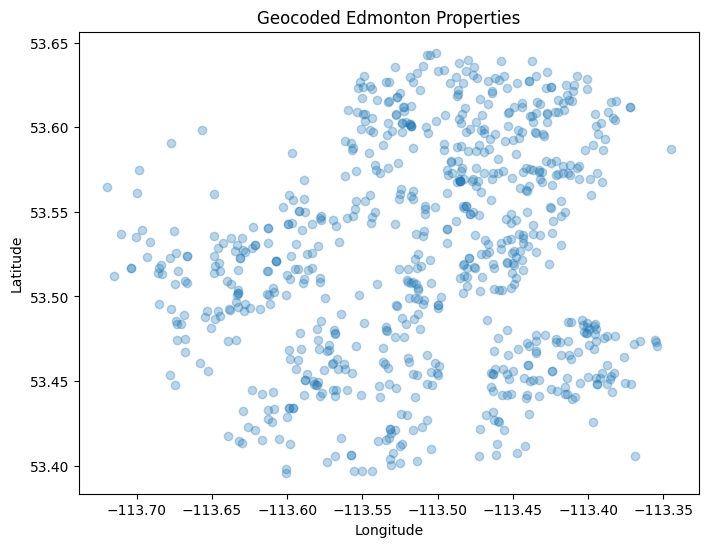

In [26]:
# ------------------------------------------
# Step 10: Visualization (Screenshot This)
# ------------------------------------------

plt.figure(figsize=(8,6))
plt.scatter(geo_sample['longitude'], geo_sample['latitude'], alpha=0.3)
plt.title("Geocoded Edmonton Properties")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#### Step 10: Visualization

We created a scatter plot to show the **locations of Edmonton properties** that were geocoded:

- **Each dot** represents a property on the map.  
- The plot shows where most properties are **clustered** and where there are fewer.  
- **Clusters** indicate popular or denser neighborhoods.  
- **Sparse areas** show neighborhoods with fewer properties.  

This visualization helps us **see how properties are distributed across the city**.

In [27]:
# ------------------------------------------
# Step 11: Save Dataset
# ------------------------------------------

geo_sample.to_csv("edmonton_geocoded_sample.csv", index=False)

print("File saved as edmonton_geocoded_sample.csv")

File saved as edmonton_geocoded_sample.csv


#### Step 11: Save Geocoded Dataset

After successfully generating latitude and longitude coordinates for a 1000-row sample of Edmonton properties, the dataset was saved as a CSV file for submission.

- **File Name:** `edmonton_geocoded_sample.csv`  
- **Contents:**  
  - `full_address` – the complete property address used for geocoding  
  - `latitude` – latitude coordinate of the property  
  - `longitude` – longitude coordinate of the property  
  - Other original columns from the sample (e.g., list price, beds, baths)  

This CSV contains **1000 geocoded property listings** from the sold listings dataset and is ready for submission as part of the assignment deliverables.